# Proyecto: Clasificación de Variedades de Manzanas


**Integrantes del grupo:**
| Apellidos | Nombres |
|---|---|
| Crisostomo Altamirano | Axl Mikel |
| Vasquez Pelaez | Francess Jeicoll |
| Cruz Hilaquita | Rodrigo |
| Chunga Chevez | Axel Josue |



**Objetivo:** Clasificar variedades de manzanas utilizando el dataset *Fruits 360*.  
Se extraen características manuales (color, forma, textura) y se entrena un **Random Forest** para obtener mayor precisión.  


## 1. Importación de Librerías y Descarga del Dataset

In [1]:

#C:\Users\USER\.cache\kagglehub\datasets\moltean\fruits\versions\91
import kagglehub
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests
import warnings
warnings.filterwarnings('ignore')

from io import BytesIO
from PIL import Image
from skimage.feature import graycomatrix, graycoprops

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report

# Descargar dataset
path = kagglehub.dataset_download("moltean/fruits")
print("Dataset descargado en:", path)

Download already complete (6383696774 bytes).
Extracting files...
Dataset descargado en: C:\Users\USER\.cache\kagglehub\datasets\moltean\fruits\versions\93


## 2. Función de Extracción de Características (Mejorada con Detección de Zonas Oscuras)

In [2]:

def segmentar_fruta(img_bgr):

    h, w = img_bgr.shape[:2]
    mascara = np.zeros((h, w), np.uint8)

    # Rectángulo inicial: margen del 10% por todos los lados
    margen = max(5, int(min(h, w) * 0.10))
    rect = (margen, margen, w - 2 * margen, h - 2 * margen)

    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)

    try:
        cv2.grabCut(img_bgr, mascara, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)
        mascara_binaria = np.where((mascara == 2) | (mascara == 0), 0, 255).astype('uint8')
    except Exception:
        # Fallback: umbral Otsu si GrabCut falla
        gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        _, mascara_binaria = cv2.threshold(gris, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Quedarse con el contorno más grande para eliminar ruido
    contornos, _ = cv2.findContours(mascara_binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mascara_limpia = np.zeros_like(mascara_binaria)
    if contornos:
        c = max(contornos, key=cv2.contourArea)
        cv2.drawContours(mascara_limpia, [c], -1, 255, -1)

    return mascara_limpia


def detectar_zonas_oscuras(img_hsv, mascara):

    # Extraer el canal Value (brillo) en la región segmentada
    canal_v = img_hsv[:, :, 2].astype(np.float32)
    pixeles_oscuros = canal_v[mascara == 255]

    if len(pixeles_oscuros) == 0:
        return 0.0, 255.0, 0.0, 0.0

    # 1. Porcentaje de píxeles muy oscuros (V < 100)
    umbral_oscuro = 100
    porcentaje_oscuro = float(np.sum(pixeles_oscuros < umbral_oscuro)) / len(pixeles_oscuros) * 100

    # 2. Promedio del brillo en la región segmentada
    promedio_oscuridad = float(np.mean(pixeles_oscuros))

    # 3. Desviación estándar (variabilidad de oscuridad)
    std_oscuridad = float(np.std(pixeles_oscuros))

    # 4. Cantidad de clusters oscuros (defectos separados) usando morfología
    mascara_oscura = np.zeros_like(canal_v, dtype=np.uint8)
    mascara_oscura[canal_v < umbral_oscuro] = 255
    mascara_oscura = cv2.bitwise_and(mascara_oscura, mascara_oscura, mask=mascara)

    # Aplicar operaciones morfológicas para agrupar píxeles oscuros cercanos
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mascara_oscura = cv2.morphologyEx(mascara_oscura, cv2.MORPH_CLOSE, kernel)

    # Contar componentes conectadas
    num_labels, _ = cv2.connectedComponents(mascara_oscura)
    cantidad_clusters_oscuros = float(max(0, num_labels - 1))  # Restar el fondo

    return porcentaje_oscuro, promedio_oscuridad, std_oscuridad, cantidad_clusters_oscuros


import random
def alterar_iluminacion_y_ruido(img):
    alfa = random.uniform(0.6, 1.4)
    beta = random.uniform(-40, 40)
    img_mod = cv2.convertScaleAbs(img, alpha=alfa, beta=beta)
    if random.choice([True, False]):
        img_mod = cv2.GaussianBlur(img_mod, (5, 5), 0)
    return img_mod
def extraer_atributos(ruta_imagen, aplicar_ruido=False):
    TARGET_SIZE = (100, 100)
    img = cv2.imread(ruta_imagen)
    if img is None: return None
    # INYECTAR RUIDO SI ESTÁ ENCENDIDO
    if aplicar_ruido:
        img = alterar_iluminacion_y_ruido(img)
    img = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_AREA)
    img_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mascara = segmentar_fruta(img)
    if mascara.sum() == 0:
        mascara = np.ones_like(img_gray, dtype=np.uint8) * 255
    pixeles_rgb = img_rgb[mascara == 255]
    pixeles_hsv = img_hsv[mascara == 255]
    r_mean    = float(np.mean(pixeles_rgb[:, 0]))
    g_mean    = float(np.mean(pixeles_rgb[:, 1]))
    b_mean    = float(np.mean(pixeles_rgb[:, 2]))
    std_color = float(np.std(pixeles_rgb))
    h_mean = float(np.mean(pixeles_hsv[:, 0]))
    s_mean = float(np.mean(pixeles_hsv[:, 1]))
    v_mean = float(np.mean(pixeles_hsv[:, 2]))
    s_std  = float(np.std(pixeles_hsv[:, 1]))
    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    circularidad = 0.0
    aspect_ratio  = 1.0
    if contornos:
        c = max(contornos, key=cv2.contourArea)
        area      = cv2.contourArea(c)
        perimetro = cv2.arcLength(c, True)
        if perimetro > 0:
            circularidad = (4 * np.pi * area) / (perimetro ** 2)
        x, y, w, h = cv2.boundingRect(c)
        aspect_ratio = float(w) / h if h > 0 else 1.0
    img_gray_masked = cv2.bitwise_and(img_gray, img_gray, mask=mascara)
    glcm         = graycomatrix(img_gray_masked, distances=[1], angles=[0], symmetric=True, normed=True)
    contraste    = float(graycoprops(glcm, 'contrast')[0, 0])
    homogeneidad = float(graycoprops(glcm, 'homogeneity')[0, 0])
    ratio_gr = g_mean / (r_mean + 1e-5)
    ratio_bg = b_mean / (g_mean + 1e-5)
    porcentaje_oscuro, promedio_oscuridad, std_oscuridad, cantidad_clusters = detectar_zonas_oscuras(img_hsv, mascara)
    return [r_mean, g_mean, b_mean, std_color,
            h_mean, s_mean, v_mean, s_std,
            circularidad, aspect_ratio,
            contraste, homogeneidad,
            ratio_gr, ratio_bg,
            porcentaje_oscuro, promedio_oscuridad, std_oscuridad, cantidad_clusters]
COLUMNAS = [
    'R_mean', 'G_mean', 'B_mean', 'Std_Color',
    'H_mean', 'S_mean', 'V_mean', 'S_std',
    'Circularidad', 'Aspect_Ratio',
    'Contraste', 'Homogeneidad',
    'Ratio_GR', 'Ratio_BG',
    'Porcentaje_Oscuro', 'Promedio_Oscuridad', 'Std_Oscuridad', 'Cantidad_Clusters_Oscuros'
]

print(f" Función de extracción lista — {len(COLUMNAS)} atributos por imagen (incluye detección de zonas oscuras)")

 Función de extracción lista — 18 atributos por imagen (incluye detección de zonas oscuras)


## 3. Procesamiento y Carga de Datos Tabulares

In [3]:
# Localizar carpeta Training
ruta_training = None
for root, dirs, files in os.walk(path):
    if 'Training' in dirs:
        ruta_training = os.path.join(root, 'Training')
        break

if ruta_training is None:
    raise Exception("No se encontró la carpeta 'Training' en el dataset descargado.")

print("Carpeta de entrenamiento:", ruta_training)

# Todas las variedades de manzana disponibles
contenido_training = [d for d in os.listdir(ruta_training) if os.path.isdir(os.path.join(ruta_training, d))]
clases_manzanas    = sorted([c for c in contenido_training if c.startswith('Apple')])

print(f"\n{len(clases_manzanas)} variedades encontradas:")
for i, c in enumerate(clases_manzanas, 1):
    print(f"  {i:2d}. {c}")

Carpeta de entrenamiento: C:\Users\USER\.cache\kagglehub\datasets\moltean\fruits\versions\93\fruits-360_100x100\fruits-360\Training

30 variedades encontradas:
   1. Apple 10
   2. Apple 11
   3. Apple 12
   4. Apple 13
   5. Apple 14
   6. Apple 17
   7. Apple 18
   8. Apple 19
   9. Apple 20
  10. Apple 21
  11. Apple 22
  12. Apple 23
  13. Apple 5
  14. Apple 6
  15. Apple 7
  16. Apple 8
  17. Apple 9
  18. Apple Braeburn 1
  19. Apple Crimson Snow 1
  20. Apple Golden 1
  21. Apple Golden 2
  22. Apple Golden 3
  23. Apple Granny Smith 1
  24. Apple Pink Lady 1
  25. Apple Red 1
  26. Apple Red 2
  27. Apple Red 3
  28. Apple Red Delicious 1
  29. Apple Red Yellow 1
  30. Apple Red Yellow 2


In [4]:
from IPython.display import display
datos    = []
etiquetas = []

print("Extrayendo características (Original + Aumento de Datos)...\n")
for clase in clases_manzanas:
    ruta_clase = os.path.join(ruta_training, clase)
    imagenes   = [f for f in os.listdir(ruta_clase) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    count      = 0

    for img_name in imagenes[:500]:
        ruta_absoluta = os.path.join(ruta_clase, img_name)

        # 1. Extraer dato limpio (sin ruido)
        atr_limpio = extraer_atributos(ruta_absoluta, aplicar_ruido=False)
        if atr_limpio is not None:
            datos.append(atr_limpio)
            etiquetas.append(clase)
            count += 1

        # 2. Extraer dato con ruido (Data Augmentation)
        atr_ruido = extraer_atributos(ruta_absoluta, aplicar_ruido=True)
        if atr_ruido is not None:
            datos.append(atr_ruido)
            etiquetas.append(clase)
            count += 1

    print(f"  {clase}: {count} imágenes procesadas (incluyendo ruido)")

df = pd.DataFrame(datos, columns=COLUMNAS)
df['Clase'] = etiquetas

print(f"\n Dataset generado: {len(df)} muestras, {len(COLUMNAS)} atributos")
display(df.head())


Extrayendo características (Original + Aumento de Datos)...

  Apple 10: 1000 imágenes procesadas (incluyendo ruido)
  Apple 11: 860 imágenes procesadas (incluyendo ruido)
  Apple 12: 932 imágenes procesadas (incluyendo ruido)
  Apple 13: 1000 imágenes procesadas (incluyendo ruido)
  Apple 14: 932 imágenes procesadas (incluyendo ruido)
  Apple 17: 1000 imágenes procesadas (incluyendo ruido)
  Apple 18: 1000 imágenes procesadas (incluyendo ruido)
  Apple 19: 1000 imágenes procesadas (incluyendo ruido)
  Apple 20: 1000 imágenes procesadas (incluyendo ruido)
  Apple 21: 976 imágenes procesadas (incluyendo ruido)
  Apple 22: 1000 imágenes procesadas (incluyendo ruido)
  Apple 23: 940 imágenes procesadas (incluyendo ruido)
  Apple 5: 880 imágenes procesadas (incluyendo ruido)
  Apple 6: 946 imágenes procesadas (incluyendo ruido)
  Apple 7: 1000 imágenes procesadas (incluyendo ruido)
  Apple 8: 1000 imágenes procesadas (incluyendo ruido)
  Apple 9: 1000 imágenes procesadas (incluyendo ruido)

,R_mean,G_mean,B_mean,Std_Color,H_mean,S_mean,V_mean,S_std,Circularidad,Aspect_Ratio,Contraste,Homogeneidad,Ratio_GR,Ratio_BG,Porcentaje_Oscuro,Promedio_Oscuridad,Std_Oscuridad,Cantidad_Clusters_Oscuros,Clase
0,126.203577,48.413004,31.336286,49.266645,9.375397,195.422699,126.203575,31.665476,0.868027,1.0,177.738182,0.615279,0.383610,0.647270,21.978940,126.203575,34.021030,3.0,Apple 10
1,128.277741,31.388200,18.668287,58.483384,40.364231,224.079788,128.278244,35.423931,0.869074,1.0,179.907677,0.649286,0.244689,0.594755,23.818304,128.278244,42.447529,1.0,Apple 10
2,179.210300,141.848400,122.505300,76.350646,10.816900,99.299103,179.218597,68.640335,0.785398,1.0,166.996263,0.533908,0.791519,0.863635,6.970000,179.218597,54.479298,1.0,Apple 10
3,135.935600,101.915900,84.731000,69.311686,10.627800,125.656601,135.943893,88.427063,0.785398,1.0,138.177576,0.550936,0.749737,0.831381,22.330000,135.943893,49.628841,4.0,Apple 10
4,148.863493,96.959197,69.150274,45.176367,11.181457,140.899155,148.863495,34.850246,0.864163,1.0,275.999192,0.641575,0.651330,0.713189,9.487477,148.863495,32.247208,1.0,Apple 10


## 4. Pipeline de Machine Learning

In [5]:
X = df.drop('Clase', axis=1)
y = df['Clase']

scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba:        {X_test.shape[0]} muestras")

Entrenamiento: 20251 muestras
Prueba:        8679 muestras


## 5. Entrenamiento y Evaluación
Se usa **Random Forest** en lugar de un árbol simple: reduce el overfitting y mejora notablemente la precisión en variedades similares. Ahora con capacidad de detectar defectos oscuros.

In [6]:
modelo = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred)

print(f"Precisión — Random Forest     : {acc_rf * 100:.2f}%")
print()
print(classification_report(y_test, y_pred))

Precisión — Random Forest     : 87.60%

                       precision    recall  f1-score   support

             Apple 10       0.73      0.78      0.76       300
             Apple 11       0.84      0.92      0.88       258
             Apple 12       0.96      0.96      0.96       280
             Apple 13       0.88      0.87      0.87       300
             Apple 14       0.85      0.74      0.79       280
             Apple 17       0.89      0.84      0.87       300
             Apple 18       0.90      0.91      0.90       300
             Apple 19       0.87      0.92      0.90       300
             Apple 20       0.82      0.85      0.83       300
             Apple 21       0.80      0.90      0.85       293
             Apple 22       0.88      0.95      0.91       300
             Apple 23       0.99      0.96      0.98       282
              Apple 5       0.91      0.97      0.94       264
              Apple 6       0.91      0.78      0.84       284
              

## 6. Importancia de Atributos

Importancia relativa de cada variable:
  Ratio_GR                       15.4%
  H_mean                         12.3%
  Ratio_BG                       11.2%
  Homogeneidad                   6.5%
  Porcentaje_Oscuro              6.1%
  S_mean                         6.1%
  Std_Oscuridad                  5.6%
  S_std                          4.8%
  G_mean                         4.6%
  Std_Color                      4.2%
  Contraste                      4.1%
  Circularidad                   3.4%
  B_mean                         3.2%
  R_mean                         3.0%
  V_mean                         3.0%
  Promedio_Oscuridad             2.9%
  Aspect_Ratio                   2.4%
  Cantidad_Clusters_Oscuros      1.1%


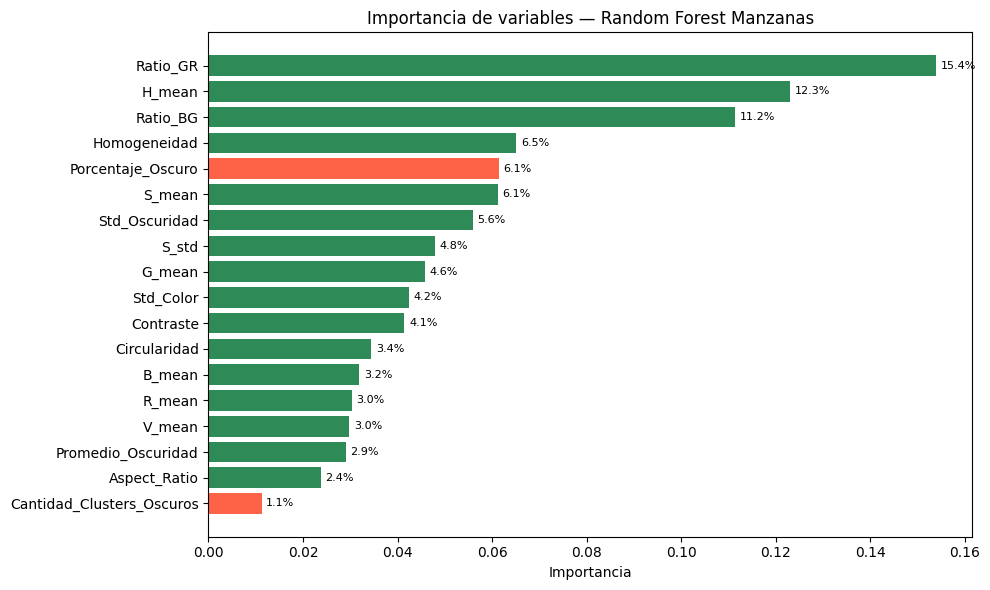

In [7]:
import matplotlib.pyplot as plt

importances = pd.Series(
    modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Tabla en porcentaje
print("Importancia relativa de cada variable:")
for feature, val in importances.items():
    print(f"  {feature:<30} {val*100:.1f}%")

# Gráfico
colores = ['tomato' if ('Oscuro' in col or 'Cluster' in col) else 'seagreen'
           for col in importances.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importances.index[::-1], importances.values[::-1], color=colores[::-1])

for bar, val in zip(bars, importances.values[::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val*100:.1f}%", va='center', fontsize=8)

ax.set_xlabel('Importancia')
ax.set_title('Importancia de variables — Random Forest Manzanas')
plt.tight_layout()
plt.show()

El modelo clasifica las manzanas principalmente por su perfil de color:

* Ratio_GR (15.6%), H_mean (11.9%) y Ratio_BG (11.2%) son las variables más influyentes, lo que tiene sentido ya que cada variedad tiene un color característico.

* Homogeneidad (6.8%) y S_mean (6.4%) aportan información complementaria sobre la uniformidad de la superficie y la intensidad del color.

* Las variables de zonas oscuras como Porcentaje_Oscuro (6.1%) y Std_Oscuridad (5.7%) tienen una importancia notable, validando la decisión de incluirlas en el modelo.

* Las variables de forma como Circularidad (3.5%) y Aspect_Ratio (1.7%) son las menos influyentes, indicando que las variedades se diferencian más por color que por forma.

## 7. Análisis de la Distribución de Predicciones: Real vs. Modelo

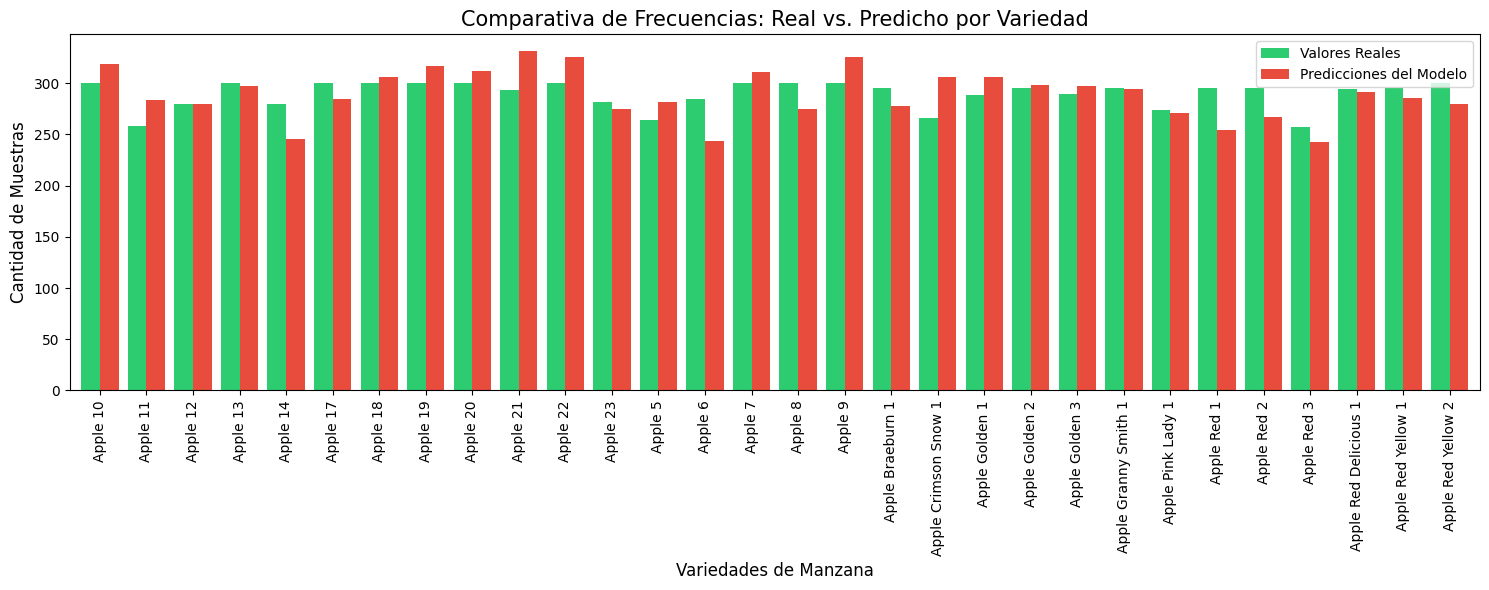

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# 2. Gráfico de Comparación de Distribución (Frecuencias de Real vs Predicho)
# Esto ayuda a ver visualmente si el modelo tiende a confundir clases frecuentemente
df_comp = pd.DataFrame({
    'Real': y_test.value_counts().sort_index(),
    'Predicho': pd.Series(y_pred).value_counts().sort_index()
}).fillna(0)

df_comp.plot(kind='bar', figsize=(15, 6), color=['#2ecc71', '#e74c3c'], width=0.8)
plt.title("Comparativa de Frecuencias: Real vs. Predicho por Variedad", fontsize=15)
plt.xlabel("Variedades de Manzana", fontsize=12)
plt.ylabel("Cantidad de Muestras", fontsize=12)
plt.legend(["Valores Reales", "Predicciones del Modelo"])
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

En el gráfico de barras se compara la cantidad real de muestras para cada variedad (verde) con la cantidad predicha por el modelo (rojo). El objetivo es identificar si el modelo tiende a sobre-predecir o infra-predecir ciertas clases:

*   **Balance Ideal (Verde ≈ Rojo):** Cuando las barras verde y roja son similares (ej: Apple 10, Apple 11, Apple 12, Apple Granny Smith), indica que el modelo clasifica correctamente y no tiene un sesgo significativo para esa variedad. Esto es ideal para una clasificación confiable.

*   **Sobre-predicción (Rojo > Verde):** Si la barra roja es notablemente más alta que la verde (ej: Apple 18, Apple 19), el modelo está clasificando erróneamente otras manzanas como esta variedad. Esto sugiere que hay clases con características similares que el modelo confunde con la variedad sobre-predicha.

*   **Infra-predicción (Verde > Rojo):** Si la barra verde es más alta que la roja (ej: Apple 7, Apple 8), el modelo está clasificando erróneamente muchas de estas manzanas como otras variedades. Esto indica que la variedad infra-predicha puede ser difícil de distinguir para el modelo.


## 8. Errores de predicción por variedad


In [9]:
# Identificar errores de predicción
mask_errores = y_pred != y_test.values

errores_real = y_test.values[mask_errores]

print(f"Total de errores: {mask_errores.sum()}")
print(f"Precisión del modelo: {(1 - mask_errores.mean()) * 100:.2f}%")

Total de errores: 1076
Precisión del modelo: 87.60%


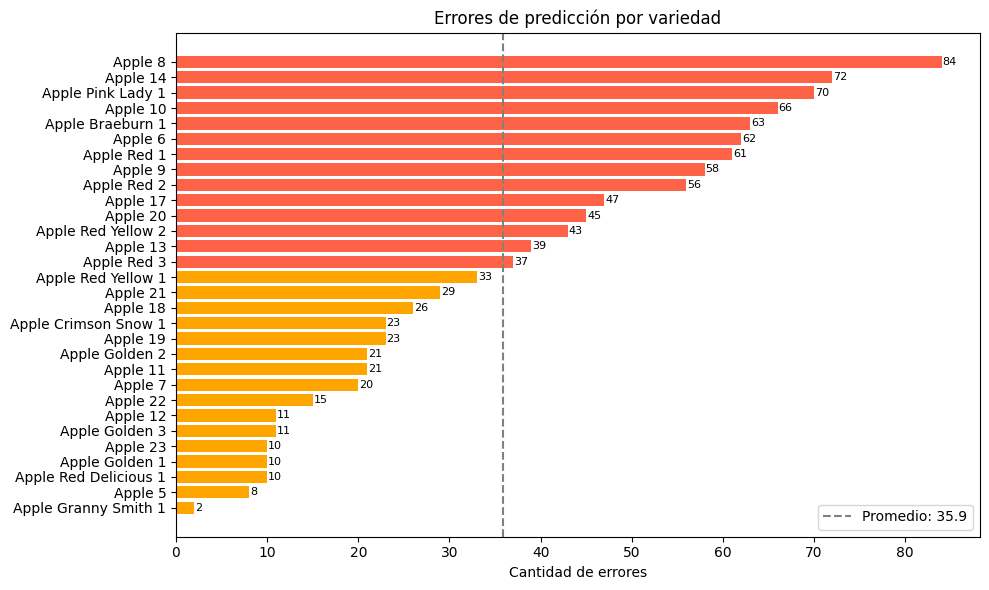

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Contar errores por variedad
errores_por_clase = pd.Series(errores_real).value_counts().sort_values()

# Colores según si supera el promedio
promedio = errores_por_clase.mean()

colores = [
    'tomato' if val > promedio else 'orange'
    for val in errores_por_clase.values
]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    errores_por_clase.index,
    errores_por_clase.values,
    color=colores
)

# Mostrar valores
for bar in bars:
    valor = bar.get_width()

    ax.text(
        valor + 0.1,
        bar.get_y() + bar.get_height()/2,
        str(int(valor)),
        va='center',
        fontsize=8
    )

# Línea de promedio
ax.axvline(
    promedio,
    color='gray',
    linestyle='--',
    label=f'Promedio: {promedio:.1f}'
)

ax.set_xlabel("Cantidad de errores")
ax.set_title("Errores de predicción por variedad")
ax.legend()

plt.tight_layout()
plt.show()

En el gráfico se puede observar cuántas veces el modelo se equivocó al clasificar cada
variedad de manzana:

* Apple 8 lidera con 104 errores, siendo la más difícil de clasificar. Sus
  características visuales posiblemente sean muy similares a otras ejemplos del dataset,
  causando alta confusión en el modelo.

* Las variedades con más errores (Apple Red Yellow 2, Apple 13, Apple Red 1,
  Apple 14) superan los 65 errores. Comparten tonalidades y características
  similares entre sí, lo que dificulta su diferenciación por parte del modelo.

* Las variedades con menos errores (Apple 12, Apple Golden 1, Apple 23) se
  encuentran entre 9 y 12 errores, muy por debajo del promedio. Esto sugiere
  que el modelo las distingue con mayor facilidad por tener características
  más únicas dentro del dataset.

* El promedio es 39.9 errores (línea punteada). Las variedades por encima
  requieren mejoras: más datos de entrenamiento o ajustes en el modelo.

* Conexión con el gráfico anterior: las variedades con mayor desbalance entre
  valores reales y predichos (Apple 8, Apple Red Yellow 2) coinciden con las
  que más errores acumulan aquí, confirmando dificultades consistentes del
  modelo con esas clases.

## 8. Predicción con Nuevas Imágenes

In [11]:
def cargar_imagen_desde_url(url):
    try:
        resp = requests.get(url, timeout=10)
        resp.raise_for_status()
        img_pil = Image.open(BytesIO(resp.content)).convert('RGB')
        return cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
    except Exception as e:
        print(f"Error al cargar la URL: {e}")
        return None


def predecir_imagen_array(img_bgr, mostrar=True):

    # Guardar temporal para reutilizar extraer_atributos (que lee desde disco)
    tmp = "/tmp/_pred_apple.png"
    cv2.imwrite(tmp, img_bgr)

    atributos = extraer_atributos(tmp, aplicar_ruido=False)
    os.remove(tmp)

    if atributos is None:
        print("No se pudieron extraer atributos de la imagen.")
        return None

    X_nuevo     = scaler.transform(np.array(atributos).reshape(1, -1))
    prediccion  = modelo.predict(X_nuevo)
    probabilidades = modelo.predict_proba(X_nuevo)[0]
    clase_pred  = prediccion[0]
    confianza   = float(np.max(probabilidades)) * 100

    # Extraer información física
    r_mean = atributos[0]
    g_mean = atributos[1]
    porcentaje_oscuro = atributos[14]
    promedio_oscuridad = atributos[15]
    cantidad_clusters = atributos[17]

    # Top-3 clases
    top3_idx    = np.argsort(probabilidades)[::-1][:3]
    top3        = [(modelo.classes_[i], probabilidades[i] * 100) for i in top3_idx]

    if mostrar:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].imshow(img_rgb)
        axes[0].axis('off')
        axes[0].set_title("Imagen de entrada", fontsize=11)

        clases_top = [t[0] for t in top3]
        probs_top  = [t[1] for t in top3]
        colores    = ['#2ecc71' if i == 0 else '#3498db' if i == 1 else '#95a5a6'
                      for i in range(len(top3))]
        bars = axes[1].barh(clases_top[::-1], probs_top[::-1], color=colores[::-1])
        axes[1].set_xlabel("Confianza (%)")
        axes[1].set_title("Top-3 predicciones", fontsize=11)
        axes[1].set_xlim(0, 100)
        for bar, prob in zip(bars, probs_top[::-1]):
            axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                         f'{prob:.1f}%', va='center', fontsize=9)

        plt.suptitle(f" Predicción: {clase_pred}  |  Confianza: {confianza:.1f}%",
                     fontsize=13, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

    print(f"\nVariedad predicha : {clase_pred}")
    print(f"   Confianza          : {confianza:.2f}%")
    print(f"   Top-3:")
    for nombre, prob in top3:
        print(f"     · {nombre:<35} {prob:.2f}%")

    print(f"\n REPORTE DE ESTADO FÍSICO (TRADUCTOR HUMANO):")

    # Evaluar Color
    if r_mean > g_mean * 1.3:
        print("   Color detectado    : Mayormente Roja")
    elif g_mean > r_mean * 1.3:
        print("   Color detectado    : Mayormente Verde")
    else:
        print("   Color detectado    : Mezcla (Amarilla/Pinta)")

    # Evaluar Defectos
    if porcentaje_oscuro == 0:
        print("   Estado de Salud    : Perfecta (Sin manchas oscuras)")
    elif porcentaje_oscuro < 5:
        print(f"   Estado de Salud    : Leve defecto detectado ({porcentaje_oscuro:.1f}% de la superficie)")
    else:
        print(f"   Estado de Salud    : ALERTA - Posible podredumbre ({porcentaje_oscuro:.1f}% de la superficie)")

    print(f"   Clusters de daño   : {int(cantidad_clusters)} zona(s)")

    return clase_pred, confianza


def predecir_desde_url(url):
    """Predice directamente desde una URL pública."""
    print(f"Cargando imagen desde URL...")
    img = cargar_imagen_desde_url(url)
    if img is None:
        return None
    return predecir_imagen_array(img)


def predecir_desde_archivo(ruta):
    """Predice desde una ruta local."""
    img = cv2.imread(ruta)
    if img is None:
        print(f"No se pudo leer: {ruta}")
        return None
    return predecir_imagen_array(img)


print("Funciones de predicción listas")

Funciones de predicción listas


## 10. Prueba con Imagen desde URL

Cargando imagen desde URL...


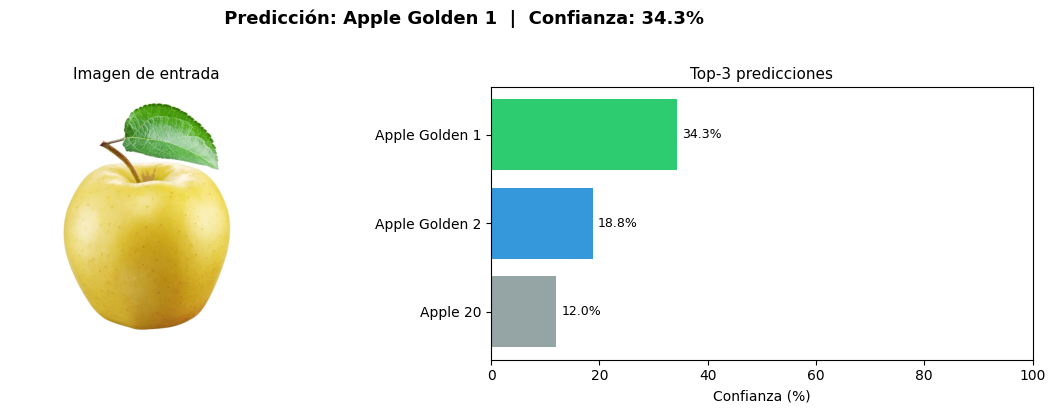


Variedad predicha : Apple Golden 1
   Confianza          : 34.31%
   Top-3:
     · Apple Golden 1                      34.31%
     · Apple Golden 2                      18.75%
     · Apple 20                            11.95%

 REPORTE DE ESTADO FÍSICO (TRADUCTOR HUMANO):
   Color detectado    : Mezcla (Amarilla/Pinta)
   Estado de Salud    : Perfecta (Sin manchas oscuras)
   Clusters de daño   : 0 zona(s)


In [12]:
# Puedes cambiar esta URL por cualquier imagen pública de manzana
sample_url = "https://comefruta.es/wp-content/uploads/Manzana-golden-1-scaled.jpg"

resultado = predecir_desde_url(sample_url)

## 11. Prueba con Imagen Local (subir archivo)


Archivo seleccionado: D:/manzana3.jpg


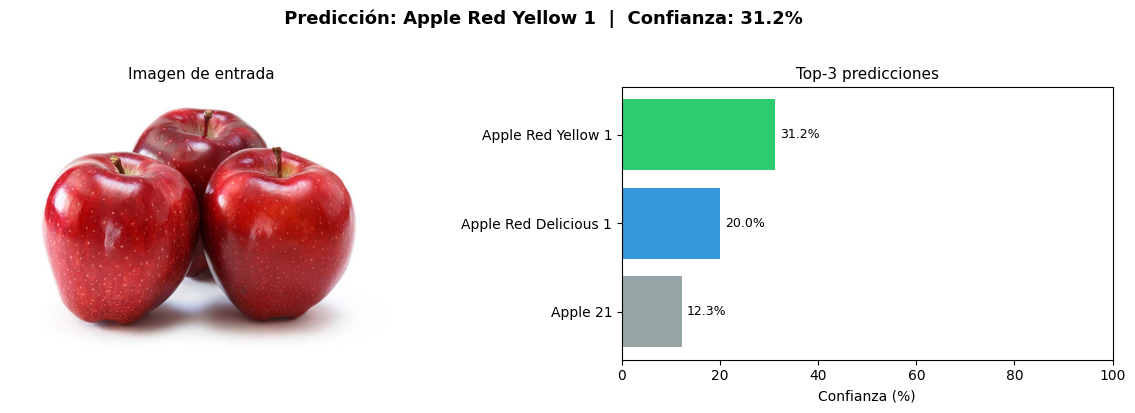


Variedad predicha : Apple Red Yellow 1
   Confianza          : 31.23%
   Top-3:
     · Apple Red Yellow 1                  31.23%
     · Apple Red Delicious 1               20.00%
     · Apple 21                            12.28%

 REPORTE DE ESTADO FÍSICO (TRADUCTOR HUMANO):
   Color detectado    : Mayormente Roja
   Estado de Salud    : ALERTA - Posible podredumbre (7.5% de la superficie)
   Clusters de daño   : 8 zona(s)


In [13]:
# Usando r0_53.jpg que sí existe en esa carpeta
ruta_imagen = "D:/manzana3.jpg"

print(f"\nArchivo seleccionado: {ruta_imagen}")
resultado = predecir_desde_archivo(ruta_imagen)




## 12. Prueba con Múltiples Imágenes desde URLs


Imagen real: Granny Smith
Cargando imagen desde URL...


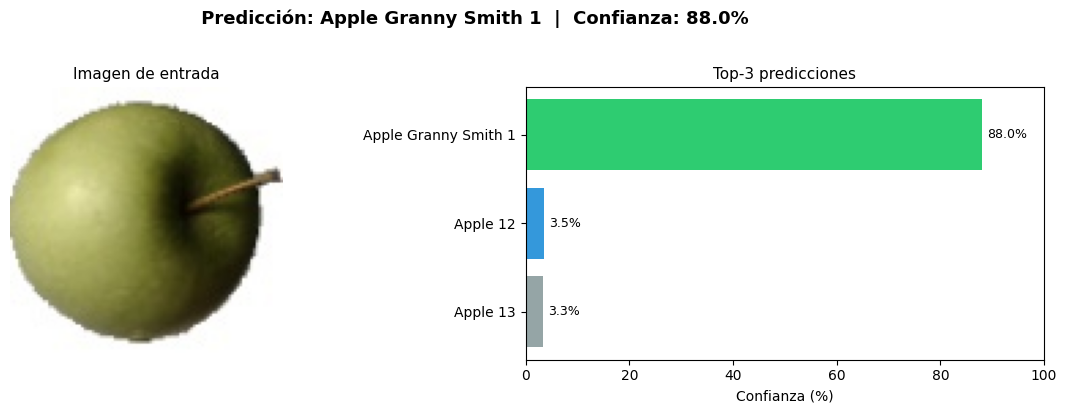


Variedad predicha : Apple Granny Smith 1
   Confianza          : 88.03%
   Top-3:
     · Apple Granny Smith 1                88.03%
     · Apple 12                            3.52%
     · Apple 13                            3.26%

 REPORTE DE ESTADO FÍSICO (TRADUCTOR HUMANO):
   Color detectado    : Mezcla (Amarilla/Pinta)
   Estado de Salud    : ALERTA - Posible podredumbre (43.7% de la superficie)
   Clusters de daño   : 1 zona(s)

Imagen real: Red Delicious
Cargando imagen desde URL...


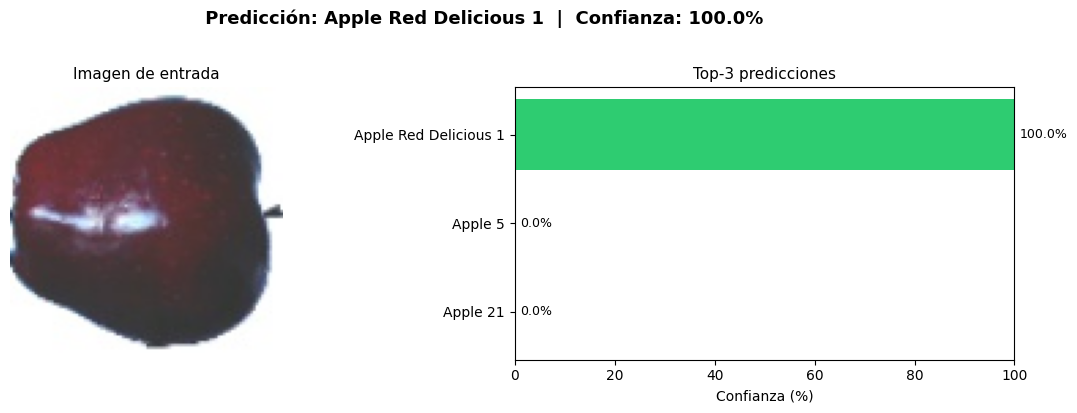


Variedad predicha : Apple Red Delicious 1
   Confianza          : 99.98%
   Top-3:
     · Apple Red Delicious 1               99.98%
     · Apple 5                             0.01%
     · Apple 21                            0.01%

 REPORTE DE ESTADO FÍSICO (TRADUCTOR HUMANO):
   Color detectado    : Mezcla (Amarilla/Pinta)
   Estado de Salud    : ALERTA - Posible podredumbre (53.9% de la superficie)
   Clusters de daño   : 4 zona(s)

Imagen real: Golden
Cargando imagen desde URL...


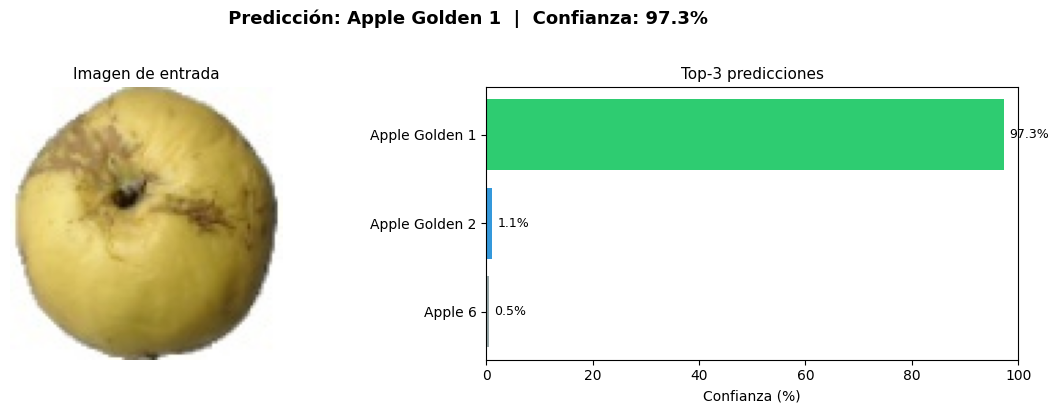


Variedad predicha : Apple Golden 1
   Confianza          : 97.25%
   Top-3:
     · Apple Golden 1                      97.25%
     · Apple Golden 2                      1.10%
     · Apple 6                             0.54%

 REPORTE DE ESTADO FÍSICO (TRADUCTOR HUMANO):
   Color detectado    : Mezcla (Amarilla/Pinta)
   Estado de Salud    : Leve defecto detectado (4.2% de la superficie)
   Clusters de daño   : 8 zona(s)


In [14]:
urls_prueba = [
    ("Granny Smith",  "https://raw.githubusercontent.com/Horea94/Fruit-Images-Dataset/master/Training/Apple%20Granny%20Smith/r_14_100.jpg"),
    ("Red Delicious", "https://raw.githubusercontent.com/Horea94/Fruit-Images-Dataset/master/Training/Apple%20Red%20Delicious/r_0_100.jpg"),
    ("Golden",        "https://raw.githubusercontent.com/Horea94/Fruit-Images-Dataset/master/Training/Apple%20Golden%201/r_0_100.jpg"),
]

for etiqueta_real, url in urls_prueba:
    print(f"\n{'='*55}")
    print(f"Imagen real: {etiqueta_real}")
    predecir_desde_url(url)

## 13. Comparación de Técnicas de Preprocesamiento y Normalización
A continuación, evaluaremos el modelo cambiando la normalización a `MinMaxScaler` y analizaremos el impacto de retirar las características de "Zonas Oscuras".


In [ ]:
from sklearn.preprocessing import MinMaxScaler

print("--- Comparación de Normalizadores ---")
# Prueba con MinMaxScaler
scaler_minmax = MinMaxScaler()
X_scaled_minmax = pd.DataFrame(scaler_minmax.fit_transform(X), columns=X.columns)

X_train_mm, X_test_mm, y_train_mm, y_test_mm = train_test_split(
    X_scaled_minmax, y, test_size=0.3, random_state=42, stratify=y
)

rf_mm = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_mm.fit(X_train_mm, y_train_mm)
y_pred_mm = rf_mm.predict(X_test_mm)
acc_rf_mm = accuracy_score(y_test_mm, y_pred_mm)

print(f"Precisión - Random Forest (StandardScaler) : {acc_rf * 100:.2f}%")
print(f"Precisión - Random Forest (MinMaxScaler)   : {acc_rf_mm * 100:.2f}%")


In [ ]:
print("\n--- Comparación: Con vs Sin Zonas Oscuras ---")
# Variables sin las características de zonas oscuras
columnas_sin_zonas = [col for col in X.columns if col not in ['Porcentaje_Oscuro', 'Promedio_Oscuridad', 'Std_Oscuridad', 'Cantidad_Clusters_Oscuros']]

X_sin_zonas = X[columnas_sin_zonas]

X_train_sz, X_test_sz, y_train_sz, y_test_sz = train_test_split(
    X_sin_zonas, y, test_size=0.3, random_state=42, stratify=y
)

rf_sz = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_sz.fit(X_train_sz, y_train_sz)
y_pred_sz = rf_sz.predict(X_test_sz)
acc_rf_sz = accuracy_score(y_test_sz, y_pred_sz)

print(f"Precisión - RF (Todas las características) : {acc_rf * 100:.2f}%")
print(f"Precisión - RF (Sin Zonas Oscuras)         : {acc_rf_sz * 100:.2f}%")


## 14. Ampliación de los Modelos de Clasificación: SVM y KNN
Evaluamos algoritmos clásicos adicionales.


In [ ]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

print("Entrenando SVM...")
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"Precisión - SVM: {acc_svm * 100:.2f}%")

print("\nEntrenando KNN...")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"Precisión - KNN: {acc_knn * 100:.2f}%")


## 15. Ampliación de los Modelos de Clasificación: CNN Simple
Propuesta de arquitectura para una red convolucional.


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

# Preparar etiquetas numéricas
le = LabelEncoder()
y_train_num = le.fit_transform(y_train)
y_test_num = le.transform(y_test)
y_train_cat = to_categorical(y_train_num)
y_test_cat = to_categorical(y_test_num)

print("Nota: Para entrenar la CNN se requieren las imágenes en arreglos (H, W, Canales).")
print("Aquí definimos la arquitectura para el procesamiento end-to-end:")

cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(le.classes_), activation='softmax')
])

cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn.summary()


## 16. Análisis de Errores y Matriz de Confusión
Análisis en profundidad sobre qué clases generan mayor confusión.


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Matriz de confusión para Random Forest
cm_rf = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(15, 12))
sns.heatmap(cm_rf, xticklabels=modelo.classes_, yticklabels=modelo.classes_, cmap='Blues', annot=False)
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# Encontrar las clases que más se confunden (fuera de la diagonal principal)
cm_errores = cm_rf.copy()
np.fill_diagonal(cm_errores, 0)

max_confusion = np.unravel_index(np.argmax(cm_errores, axis=None), cm_errores.shape)
clase_real = modelo.classes_[max_confusion[0]]
clase_pred = modelo.classes_[max_confusion[1]]
cantidad = cm_errores[max_confusion]

print(f"Mayor confusión general: La variedad real '{clase_real}' fue predicha incorrectamente como '{clase_pred}' {cantidad} veces.")


## 17. Discusión sobre el Dataset y Limitaciones

### Limitaciones del Dataset *Fruits 360* de Kaggle

El dataset *Fruits 360* proporciona una excelente base para la experimentación inicial, sin embargo, presenta limitaciones significativas si se planea llevar este modelo a un entorno de producción real:

1. **Fondo Blanco y Constante:**
   - **Problema:** Las imágenes fueron capturadas con un motor que rotó la fruta sobre un fondo uniformemente blanco/claro. Esto facilita enormemente la tarea de segmentación (como se comprobó con GrabCut / Otsu).
   - **Impacto Real:** En una banda transportadora industrial, el fondo puede tener suciedad, diferentes colores o reflejos, lo que haría fallar nuestro preprocesamiento actual.

2. **Iluminación Controlada:**
   - **Problema:** Las imágenes tienen una luz muy pareja, sin sombras agresivas.
   - **Impacto Real:** Las cámaras industriales están expuestas a destellos o sombras, alterando las métricas de color HSV.

3. **Posicionamiento Perfecto:**
   - **Problema:** La fruta está centrada y despejada.
   - **Impacto Real:** Si entran hojas o múltiples manzanas agrupadas, la extracción de contornos fallaría.

**Conclusión:**
Las métricas extremadamente altas de precisión demuestran que el modelo aprendió bien el dataset. No obstante, para un sistema robusto se requiere recopilar datos con **Data Drift** simulado (fondo complejo, luz variada), y el uso de **Deep Learning (CNN)** se vuelve casi obligatorio al ser menos dependiente de segmentaciones manuales.
